In [18]:
import pandas as pd

df = pd.read_csv("co2_mm_mlo.csv")

# Create a proper date from year and month
df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

# Make date the index
df = df.set_index("date")
df = df.asfreq("MS") #tells pandas that observations occur at the start of every month

print(df.head())

            year  month  decimal date  average  deseasonalized  ndays  sdev  \
date                                                                          
1958-03-01  1958      3     1958.2027   315.71          314.44     -1 -9.99   
1958-04-01  1958      4     1958.2877   317.45          315.16     -1 -9.99   
1958-05-01  1958      5     1958.3699   317.51          314.69     -1 -9.99   
1958-06-01  1958      6     1958.4548   317.27          315.15     -1 -9.99   
1958-07-01  1958      7     1958.5370   315.87          315.20     -1 -9.99   

             unc  
date              
1958-03-01 -0.99  
1958-04-01 -0.99  
1958-05-01 -0.99  
1958-06-01 -0.99  
1958-07-01 -0.99  


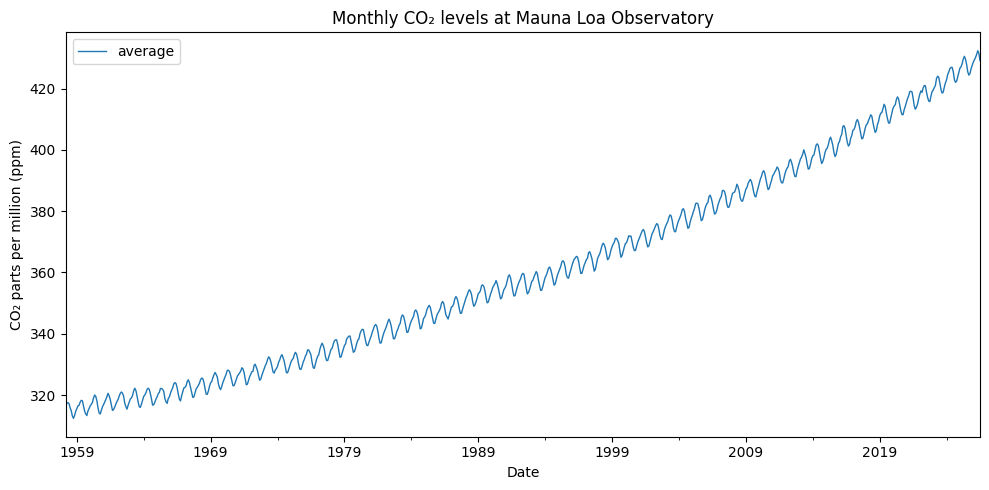

In [19]:
import matplotlib.pyplot as plt

df.plot(
    y="average",
    figsize=(10, 5),
    linewidth=1
)

plt.title("Monthly CO₂ levels at Mauna Loa Observatory")
plt.xlabel("Date")
plt.ylabel("CO₂ parts per million (ppm)")
plt.tight_layout()
plt.show()

In [20]:
from statsmodels.tsa.api import SimpleExpSmoothing
model = SimpleExpSmoothing(df["average"])
model_single_fit = model.fit()